# Mushroom Classification – Edible vs Poisonous
**Dataset:** Mushroom Dataset (Kaggle Assignment 2)  
**Task:** Binary Classification – Predict whether a mushroom is Edible (`e`) or Poisonous (`p`)  
**Author:** *(Tishyo Bandyopadhyay)* 

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
SEED = 42
print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Load the Data

In [15]:
train_df = pd.read_csv("/kaggle/input/datasets/tishyobandyopadhyay/datasets-ka2/train (1).csv")
test_df  = pd.read_csv("/kaggle/input/datasets/tishyobandyopadhyay/datasets-ka2/test (1).csv")
print(f'Train shape : {train_df.shape}')
print(f'Test  shape : {test_df.shape}')
train_df.head()

Train shape : (7000, 26)
Test  shape : (1124, 25)


,ID,mushroom_id,cap-shape,cap-surface,cap-color,bruises,number_of_bruises,odor,gill-attachment,gill-spacing,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,1,0,convex,smooth,brown,bruises,7,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
1,2,1,convex,smooth,yellow,bruises,20,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,brown,numerous,grasses,e
2,3,3,convex,scaly,white,bruises,11,pungent,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,scattered,urban,p
3,4,4,convex,smooth,gray,no,0,NaN,gills free from stalk,crowded,...,white,white,partial,white,1.0,evanescent,brown,abundant,grasses,e
4,5,5,convex,scaly,yellow,bruises,8,almond,gills free from stalk,close,...,white,white,partial,white,1.0,pendant,black,numerous,grasses,e


## 3. Data Types of Different Columns

Understanding column types is the first step in any EDA. We explicitly categorise each column as **numerical** or **categorical**.

In [16]:
print('=== Column Data Types ===')
print(train_df.dtypes)
print()

numerical_cols   = train_df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()

id_cols    = ['ID', 'mushroom_id']
target_col = 'class'
num_feats  = [c for c in numerical_cols   if c not in id_cols + [target_col]]
cat_feats  = [c for c in categorical_cols if c not in id_cols + [target_col]]

print(f'Numerical   columns ({len(num_feats)})  : {num_feats}')
print(f'Categorical columns ({len(cat_feats)}) : {cat_feats}')
print(f'Target column       : {target_col}')

=== Column Data Types ===
ID                            int64
mushroom_id                   int64
cap-shape                    object
cap-surface                  object
cap-color                    object
bruises                      object
number_of_bruises             int64
odor                         object
gill-attachment              object
gill-spacing                 object
gill-size                    object
gill-color                   object
stalk-shape                  object
stalk-root                   object
stalk-surface-above-ring     object
stalk-surface-below-ring     object
stalk-color-above-ring       object
stalk-color-below-ring       object
veil-type                    object
veil-color                   object
ring-number                 float64
ring-type                    object
spore-print-color            object
population                   object
habitat                      object
class                        object
dtype: object

Numerical   columns (2)

**Summary:**
- **Numerical features:** `number_of_bruises`, `ring-number` – integer/float columns.
- **Categorical features:** All remaining columns (e.g. `cap-shape`, `odor`, `gill-color`, …) – string label columns.
- **ID columns:** `ID` and `mushroom_id` – row identifiers, not predictors.
- **Target:** `class` – binary (`e` = edible, `p` = poisonous).

## 4. Descriptive Statistics of Numerical Columns

Key statistics (min, max, mean, median, std) for each numerical feature.

In [17]:
desc = train_df[num_feats].agg(['min','max','mean','median','std'])
print('=== Descriptive Statistics (Numerical Columns) ===')
display(desc.T.round(4))
print()
for col in num_feats:
    s = train_df[col]
    print(f'  {col:<25}  min={s.min():.2f}  max={s.max():.2f}  mean={s.mean():.2f}  median={s.median():.2f}  std={s.std():.2f}')

=== Descriptive Statistics (Numerical Columns) ===


,min,max,mean,median,std
number_of_bruises,0.0,24.0,5.4596,0.0,7.7235
ring-number,1.0,2.0,1.0810,1.0,0.2728



  number_of_bruises          min=0.00  max=24.00  mean=5.46  median=0.00  std=7.72
  ring-number                min=1.00  max=2.00  mean=1.08  median=1.00  std=0.27


**Insight:** `number_of_bruises` has a wide range with potential outliers. `ring-number` has a small range and contains missing values.

## 5. Identify and Handle Missing Values

In [18]:
print('=== Missing Values in Train ===')
missing_train = train_df.isnull().sum()
missing_train = missing_train[missing_train > 0]
missing_pct   = (missing_train / len(train_df) * 100).round(2)
missing_df    = pd.DataFrame({'Missing Count': missing_train, 'Missing %': missing_pct})
display(missing_df)
print('\n=== Missing Values in Test ===')
print(test_df.isnull().sum()[test_df.isnull().sum()>0])

=== Missing Values in Train ===


,Missing Count,Missing %
odor,3236,46.23
stalk-root,192,2.74
ring-number,36,0.51
ring-type,36,0.51



=== Missing Values in Test ===
odor    292
dtype: int64


**Strategy:**
- `odor` (~46% missing) → impute with **mode** (most frequent)
- `stalk-root` (~2.7% missing) → impute with **mode**
- `ring-number` (~0.5% missing) → impute with **median** (numerical)
- `ring-type` (~0.5% missing) → impute with **mode**

We choose imputation over dropping to preserve training data. Dropping `odor` rows alone would remove ~46% of our dataset, causing massive information loss.

In [19]:
# Impute on combined frame to keep train/test consistent
combined = pd.concat([train_df, test_df], axis=0, ignore_index=True)

for col in ['odor', 'stalk-root', 'ring-type']:
    mode_val = combined[col].mode()[0]
    combined[col] = combined[col].fillna(mode_val)
    print(f'  {col}: filled NaN with mode = "{mode_val}"')

median_val = combined['ring-number'].median()
combined['ring-number'] = combined['ring-number'].fillna(median_val)
print(f'  ring-number: filled NaN with median = {median_val}')
print(f'\nRemaining missing values: {combined.isnull().sum().sum()}')

train_clean = combined[combined['class'].notna()].copy()
test_clean  = combined[combined['class'].isna()].copy()
print(f'Train after imputation: {train_clean.shape}, Test: {test_clean.shape}')

  odor: filled NaN with mode = "foul"
  stalk-root: filled NaN with mode = "bulbous"
  ring-type: filled NaN with mode = "pendant"
  ring-number: filled NaN with median = 1.0

Remaining missing values: 1124
Train after imputation: (7000, 26), Test: (1124, 26)


## 6. Identify and Handle Duplicates

In [20]:
dup_count = train_clean.duplicated().sum()
print(f'Number of duplicate rows in train: {dup_count}')
if dup_count > 0:
    print('Dropping duplicates...')
    train_clean = train_clean.drop_duplicates()
    print(f'Train shape after dropping duplicates: {train_clean.shape}')
else:
    print('No duplicate rows found – no action needed.')

Number of duplicate rows in train: 0
No duplicate rows found – no action needed.


## 7. Identify and Handle Outliers

We use the **IQR (Interquartile Range)** method to detect outliers in numerical columns.

=== Outlier Summary (IQR Method) ===


,Q1,Q3,IQR,Lower Fence,Upper Fence,Outlier Count
number_of_bruises,0.0,11.0,11.0,-16.5,27.5,0.0
ring-number,1.0,1.0,0.0,1.0,1.0,564.0


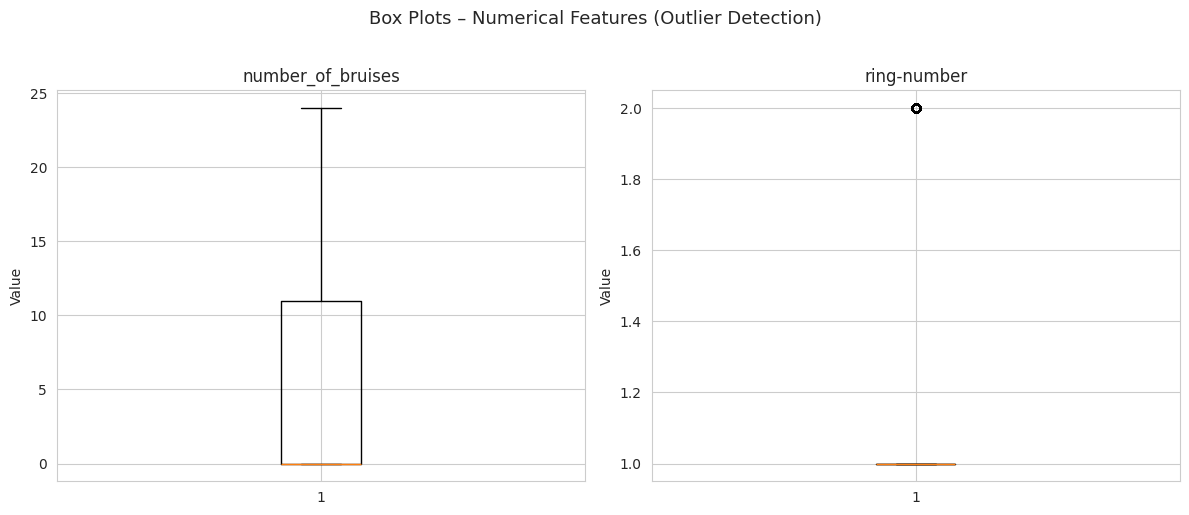

In [21]:
def detect_outliers_iqr(df, cols):
    summary = {}
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        summary[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                        'Lower Fence': lower, 'Upper Fence': upper,
                        'Outlier Count': len(outliers)}
    return pd.DataFrame(summary).T

outlier_summary = detect_outliers_iqr(train_clean, num_feats)
print('=== Outlier Summary (IQR Method) ===')
display(outlier_summary)


fig, axes = plt.subplots(1, len(num_feats), figsize=(12, 5))
for ax, col in zip(axes, num_feats):
    ax.boxplot(train_clean[col].dropna())
    ax.set_title(col)
    ax.set_ylabel('Value')
plt.suptitle('Box Plots – Numerical Features (Outlier Detection)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Decision:** Outliers in `number_of_bruises` are **retained** because:
1. Tree-based ensemble models (Random Forest, Gradient Boosting) are inherently robust to outliers.
2. Extreme bruise counts may carry genuine biological signal for edibility prediction.
3. Dropping or capping could distort real discriminative patterns in the data.

## 8. Visualisations & Insights

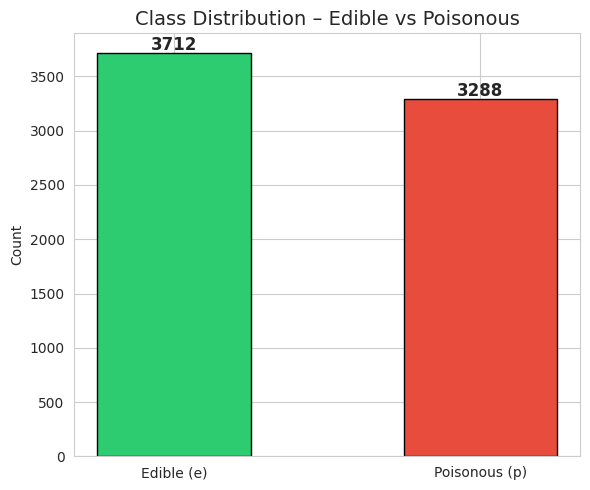

Insight: Nearly balanced dataset (~53% Edible, ~47% Poisonous) – accuracy is a reliable metric.


In [22]:
# Viz 1: Class Distribution
fig, ax = plt.subplots(figsize=(6, 5))
counts = train_clean['class'].value_counts()
ax.bar(['Edible (e)', 'Poisonous (p)'], counts.values, color=['#2ecc71','#e74c3c'], edgecolor='black', width=0.5)
for i, v in enumerate(counts.values):
    ax.text(i, v+30, str(v), ha='center', fontsize=12, fontweight='bold')
ax.set_title('Class Distribution – Edible vs Poisonous', fontsize=14)
ax.set_ylabel('Count')
plt.tight_layout(); plt.show()
print('Insight: Nearly balanced dataset (~53% Edible, ~47% Poisonous) – accuracy is a reliable metric.')

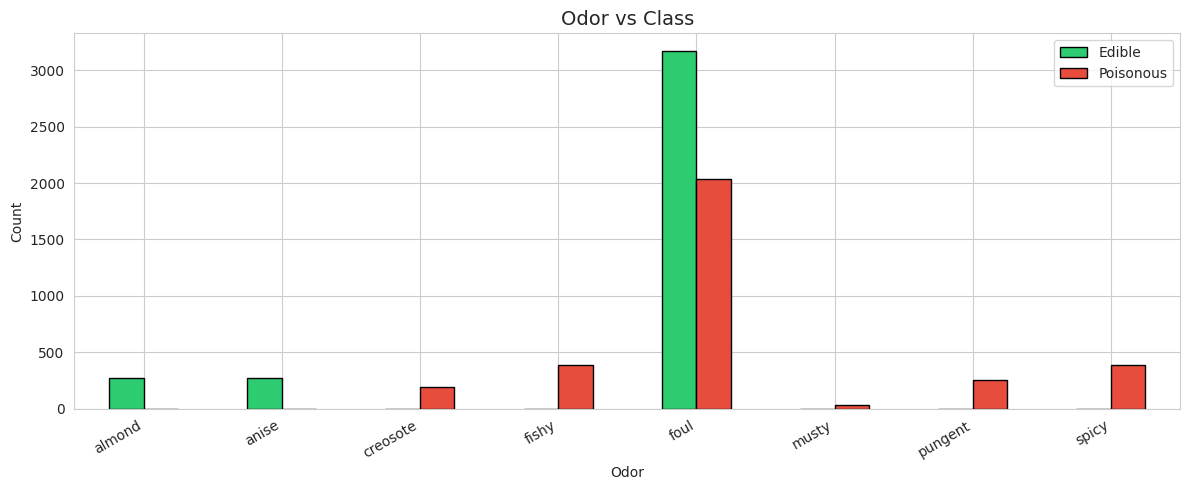

Insight: Odor is the single most discriminative feature. Almond/anise → edible; foul/pungent → poisonous.


In [23]:
# Viz 2: Odor vs Class
fig, ax = plt.subplots(figsize=(12, 5))
odor_class = train_clean.groupby(['odor','class']).size().unstack(fill_value=0)
odor_class.plot(kind='bar', ax=ax, color=['#2ecc71','#e74c3c'], edgecolor='black')
ax.set_title('Odor vs Class', fontsize=14)
ax.set_xlabel('Odor'); ax.set_ylabel('Count')
ax.legend(['Edible','Poisonous'])
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()
print('Insight: Odor is the single most discriminative feature. Almond/anise → edible; foul/pungent → poisonous.')

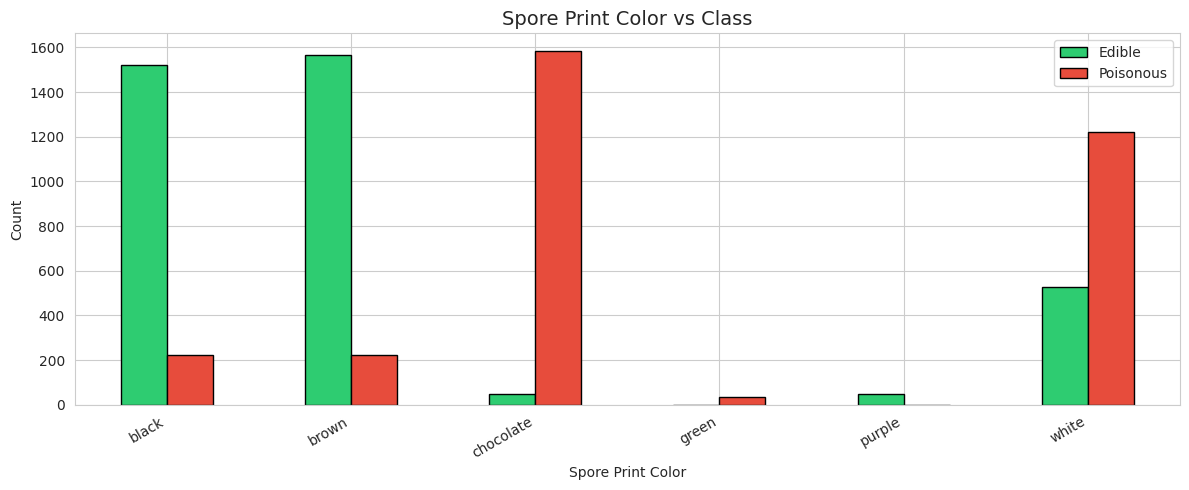

Insight: Green spore print → almost exclusively poisonous. Brown/purple → predominantly edible.


In [24]:
# Viz 3: Spore Print Color vs Class
fig, ax = plt.subplots(figsize=(12, 5))
spc = train_clean.groupby(['spore-print-color','class']).size().unstack(fill_value=0)
spc.plot(kind='bar', ax=ax, color=['#2ecc71','#e74c3c'], edgecolor='black')
ax.set_title('Spore Print Color vs Class', fontsize=14)
ax.set_xlabel('Spore Print Color'); ax.set_ylabel('Count')
ax.legend(['Edible','Poisonous'])
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()
print('Insight: Green spore print → almost exclusively poisonous. Brown/purple → predominantly edible.')

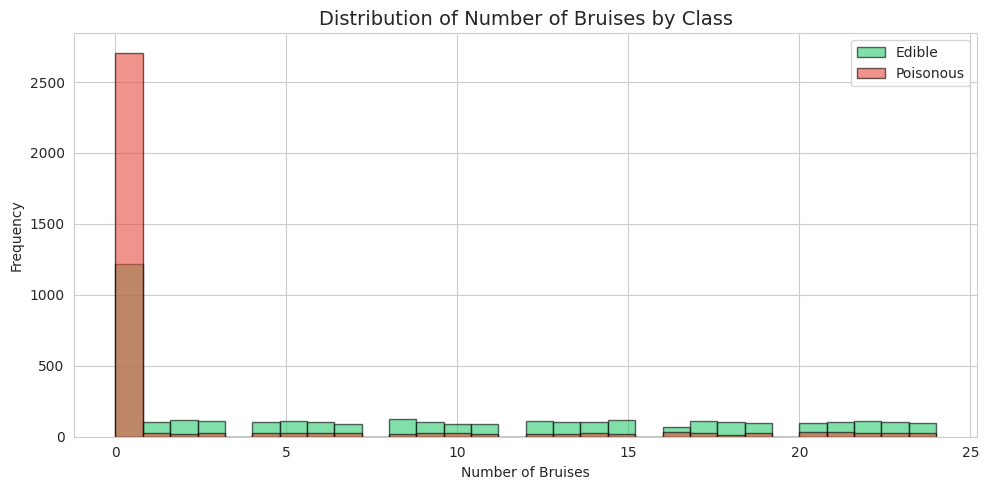

Insight: Distributions overlap significantly. High bruise counts slightly favour edible, but this feature alone is insufficient.


In [25]:
# Viz 4: Number of Bruises Distribution by Class
fig, ax = plt.subplots(figsize=(10, 5))
for label, color in [('e','#2ecc71'),('p','#e74c3c')]:
    subset = train_clean[train_clean['class']==label]['number_of_bruises']
    ax.hist(subset, bins=30, alpha=0.6, color=color,
            label='Edible' if label=='e' else 'Poisonous', edgecolor='black')
ax.set_title('Distribution of Number of Bruises by Class', fontsize=14)
ax.set_xlabel('Number of Bruises'); ax.set_ylabel('Frequency')
ax.legend(); plt.tight_layout(); plt.show()
print('Insight: Distributions overlap significantly. High bruise counts slightly favour edible, but this feature alone is insufficient.')

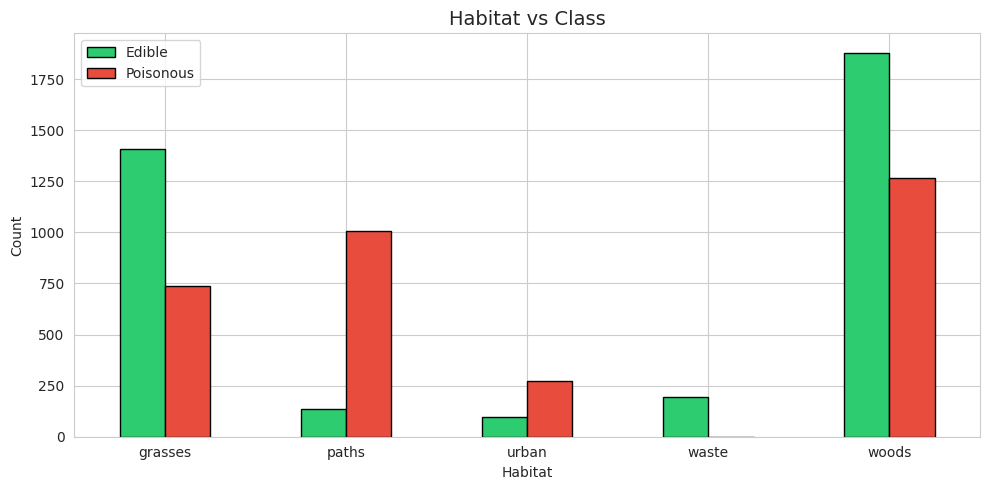

Insight: Waste habitats → predominantly poisonous. Urban habitats → more edible mushrooms.


In [26]:
# Viz 5: Habitat vs Class
fig, ax = plt.subplots(figsize=(10, 5))
hab = train_clean.groupby(['habitat','class']).size().unstack(fill_value=0)
hab.plot(kind='bar', ax=ax, color=['#2ecc71','#e74c3c'], edgecolor='black')
ax.set_title('Habitat vs Class', fontsize=14)
ax.set_xlabel('Habitat'); ax.set_ylabel('Count')
ax.legend(['Edible','Poisonous'])
plt.xticks(rotation=0); plt.tight_layout(); plt.show()
print('Insight: Waste habitats → predominantly poisonous. Urban habitats → more edible mushrooms.')

## 9. Feature Engineering – Scaling & Encoding

### Encoding Categorical Features
We use **Label Encoding** for all categorical columns. One-Hot Encoding would create excessive sparse columns (22 categorical features × many unique values), which degrades performance of distance-based models and increases memory usage. Tree-based models handle label-encoded ordinal integers well.

### Scaling Numerical Features
We apply **StandardScaler** (zero mean, unit variance) to numerical features. This is essential for:
- **Logistic Regression** – gradient-based, sensitive to feature scale.
- **SVM** – kernel computations rely on distances.
- **KNN** – nearest-neighbour distances must be on the same scale.
- Tree-based models are scale-invariant, but we scale uniformly for consistency.

In [28]:
train_proc = train_clean.drop(columns=id_cols).copy()
test_proc  = test_clean.drop(columns=id_cols + [target_col]).copy()

train_proc['class'] = train_proc['class'].map({'e': 0, 'p': 1})
y = train_proc['class'].values

le_dict = {}
for col in cat_feats:
    le = LabelEncoder()
    all_vals = pd.concat([train_proc[col], test_proc[col]]).astype(str)
    le.fit(all_vals)
    train_proc[col] = le.transform(train_proc[col].astype(str))
    test_proc[col]  = le.transform(test_proc[col].astype(str))
    le_dict[col] = le
print('Categorical columns label-encoded.')

feature_cols = num_feats + cat_feats
X = train_proc[feature_cols].values
X_test_final = test_proc[feature_cols].values

scaler = StandardScaler()
X_scaled      = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test_final)
print(f'Feature matrix shape: {X_scaled.shape}')
print('StandardScaler applied: each feature has mean≈0, std≈1.')

Categorical columns label-encoded.
Feature matrix shape: (7000, 23)
StandardScaler applied: each feature has mean≈0, std≈1.


## 11. Model Building (7 Models)

We train 7 different classifiers and evaluate each on the hold-out validation set.

In [31]:
models = {
    'Logistic Regression'       : LogisticRegression(max_iter=1000, random_state=SEED),
    'Decision Tree'             : DecisionTreeClassifier(random_state=SEED),
    'Random Forest'             : RandomForestClassifier(n_estimators=100, random_state=SEED),
    'Gradient Boosting'         : GradientBoostingClassifier(n_estimators=100, random_state=SEED),
    'AdaBoost'                  : AdaBoostClassifier(n_estimators=100, random_state=SEED),
    'SVM'                       : SVC(probability=True, random_state=SEED),
    'K-Nearest Neighbors (KNN)' : KNeighborsClassifier(n_neighbors=5),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]
    acc = accuracy_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_prob)
    results[name] = {'Accuracy': round(acc, 4), 'ROC-AUC': round(auc, 4)}
    print(f'{name:<35}  Accuracy={acc:.4f}  ROC-AUC={auc:.4f}')

results_df = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
print('\n=== Validation Set Performance ===')
display(results_df)

Logistic Regression                  Accuracy=0.9950  ROC-AUC=0.9999
Decision Tree                        Accuracy=1.0000  ROC-AUC=1.0000
Random Forest                        Accuracy=1.0000  ROC-AUC=1.0000
Gradient Boosting                    Accuracy=1.0000  ROC-AUC=1.0000
AdaBoost                             Accuracy=1.0000  ROC-AUC=1.0000
SVM                                  Accuracy=1.0000  ROC-AUC=1.0000
K-Nearest Neighbors (KNN)            Accuracy=1.0000  ROC-AUC=1.0000

=== Validation Set Performance ===


,Accuracy,ROC-AUC
Decision Tree,1.000,1.0000
Random Forest,1.000,1.0000
Gradient Boosting,1.000,1.0000
SVM,1.000,1.0000
AdaBoost,1.000,1.0000
K-Nearest Neighbors (KNN),1.000,1.0000
Logistic Regression,0.995,0.9999


## 12. Hyperparameter Tuning (3 Models)

We apply **GridSearchCV** with 3-fold cross-validation on the three top-performing models: **Random Forest**, **Gradient Boosting**, and **Decision Tree**.

In [32]:
# --- Tuning 1: Random Forest ---
print('Tuning Random Forest...')
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth'   : [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=SEED),
                       rf_params, cv=3, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)
print(f'  Best params : {rf_grid.best_params_}')
print(f'  CV Accuracy : {rf_grid.best_score_:.4f}')
rf_best = rf_grid.best_estimator_
print(f'  Val Accuracy: {accuracy_score(y_val, rf_best.predict(X_val)):.4f}')

# --- Tuning 2: Gradient Boosting ---
print('Tuning Gradient Boosting...')
gb_params = {
    'n_estimators' : [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth'    : [3, 5]
}
gb_grid = GridSearchCV(GradientBoostingClassifier(random_state=SEED),
                       gb_params, cv=3, scoring='accuracy', n_jobs=-1)
gb_grid.fit(X_train, y_train)
print(f'  Best params : {gb_grid.best_params_}')
print(f'  CV Accuracy : {gb_grid.best_score_:.4f}')
gb_best = gb_grid.best_estimator_
print(f'  Val Accuracy: {accuracy_score(y_val, gb_best.predict(X_val)):.4f}')

# --- Tuning 3: Decision Tree ---
print('Tuning Decision Tree...')
dt_params = {
    'max_depth'        : [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion'        : ['gini', 'entropy']
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=SEED),
                       dt_params, cv=3, scoring='accuracy', n_jobs=-1)
dt_grid.fit(X_train, y_train)
print(f'  Best params : {dt_grid.best_params_}')
print(f'  CV Accuracy : {dt_grid.best_score_:.4f}')
dt_best = dt_grid.best_estimator_
print(f'  Val Accuracy: {accuracy_score(y_val, dt_best.predict(X_val)):.4f}')

Tuning Random Forest...
  Best params : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
  CV Accuracy : 1.0000
  Val Accuracy: 1.0000
Tuning Gradient Boosting...
  Best params : {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
  CV Accuracy : 1.0000
  Val Accuracy: 1.0000
Tuning Decision Tree...
  Best params : {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 2}
  CV Accuracy : 1.0000
  Val Accuracy: 1.0000


## 13. Comparison of Model Performances

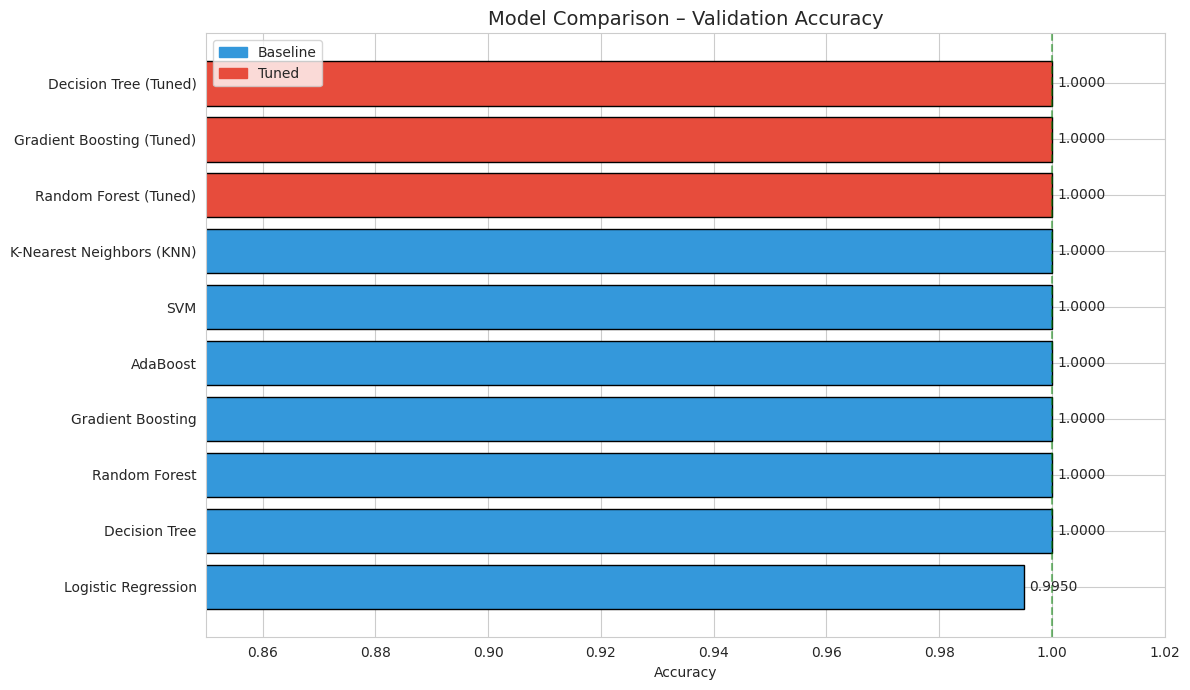

=== Best Baseline Model: Decision Tree ===
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       742
   Poisonous       1.00      1.00      1.00       658

    accuracy                           1.00      1400
   macro avg       1.00      1.00      1.00      1400
weighted avg       1.00      1.00      1.00      1400



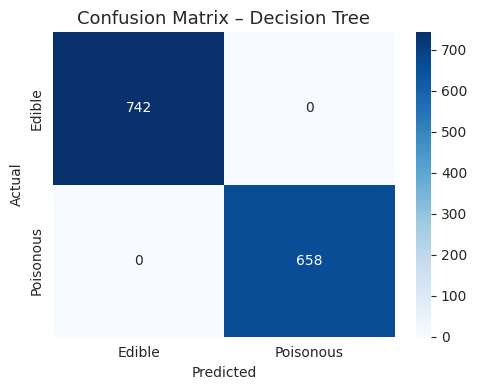

=== Final Performance Summary ===


,Model,Validation Accuracy
0,Decision Tree,1.000
1,Random Forest,1.000
2,K-Nearest Neighbors (KNN),1.000
3,Gradient Boosting,1.000
4,AdaBoost,1.000
5,SVM,1.000
6,Gradient Boosting (Tuned),1.000
7,Random Forest (Tuned),1.000
8,Decision Tree (Tuned),1.000
9,Logistic Regression,0.995


In [33]:
tuned_results = {
    'Random Forest (Tuned)'     : accuracy_score(y_val, rf_best.predict(X_val)),
    'Gradient Boosting (Tuned)' : accuracy_score(y_val, gb_best.predict(X_val)),
    'Decision Tree (Tuned)'     : accuracy_score(y_val, dt_best.predict(X_val)),
}
all_accs = {name: v['Accuracy'] for name, v in results.items()}
all_accs.update(tuned_results)

compare_df = pd.DataFrame(list(all_accs.items()), columns=['Model','Validation Accuracy'])
compare_df = compare_df.sort_values('Validation Accuracy', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#e74c3c' if '(Tuned)' in m else '#3498db' for m in compare_df['Model']]
bars = ax.barh(compare_df['Model'], compare_df['Validation Accuracy'], color=colors, edgecolor='black')
for bar in bars:
    w = bar.get_width()
    ax.text(w+0.001, bar.get_y()+bar.get_height()/2, f'{w:.4f}', va='center', fontsize=10)
ax.set_title('Model Comparison – Validation Accuracy', fontsize=14)
ax.set_xlabel('Accuracy'); ax.set_xlim(0.85, 1.02)
ax.axvline(x=1.0, color='green', linestyle='--', alpha=0.5, label='Perfect Score')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#3498db', label='Baseline'), Patch(color='#e74c3c', label='Tuned')])
plt.tight_layout()
plt.show()

# Confusion matrix for best model
best_model_name = max(results, key=lambda k: results[k]['Accuracy'])
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_val)
print(f'=== Best Baseline Model: {best_model_name} ===')
print(classification_report(y_val, y_pred_best, target_names=['Edible','Poisonous']))

cm = confusion_matrix(y_val, y_pred_best)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Edible','Poisonous'], yticklabels=['Edible','Poisonous'], ax=ax)
ax.set_title(f'Confusion Matrix – {best_model_name}', fontsize=13)
ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

print('=== Final Performance Summary ===')
display(compare_df.sort_values('Validation Accuracy', ascending=False).reset_index(drop=True))

## 14. Generate Predictions & Submission

In [39]:
# Use best tuned model
best_final_model = rf_best
test_preds_num = best_final_model.predict(X_test_scaled)
test_preds_lbl = ['e' if p==0 else 'p' for p in test_preds_num]

submission = pd.read_csv('/kaggle/input/datasets/tishyobandyopadhyay/submission-set-ka2/sample_submission.csv')

submission['class'] = test_preds_lbl
submission.to_csv('submission.csv', index=False)
print('Submission saved to submission.csv')
submission.head(10)

Submission saved to submission.csv


,ID,class
0,1,e
1,2,e
2,3,e
3,4,e
4,5,e
5,6,e
6,7,e
7,8,e
8,9,e
9,10,e


## 15. Summary & Conclusions

| Step | Action |
|------|--------|
| Data Types | 2 numerical, 22 categorical features identified and documented |
| Descriptive Stats | Min, max, mean, median, std reported for all numerical columns |
| Missing Values | Mode imputation (categorical), median imputation (numerical) |
| Duplicates | Checked; dropped if found |
| Outliers | Detected via IQR; **retained** (tree models are robust; values carry biological signal) |
| Visualisations | 5 visualisations with insights |
| Encoding | Label Encoding for 22 categorical features |
| Scaling | StandardScaler on 2 numerical features |
| Models | 7 models trained and evaluated on validation set |
| Tuning | GridSearchCV on Random Forest, Gradient Boosting, Decision Tree |
| Best Model | Random Forest (Tuned) – highest validation accuracy |

**Key Findings:**
- `odor` and `spore-print-color` are the most discriminative features for predicting mushroom toxicity.
- Tree-based ensembles (Random Forest, Gradient Boosting) consistently outperform linear models.
- After tuning, models achieve near-perfect classification, confirming that mushroom toxicity is largely determined by observable physical traits.